# Walmart Retail Sales Analytics

## Business Question
**What factors drive weekly sales across Walmart stores, and can a simple model help explain sales performance?**

## Objective
This project analyzes historical Walmart store sales to identify the main operational and economic factors associated with weekly sales performance. The analysis combines data preparation, KPI analysis, SQL, visualization, correlation analysis, and linear regression to translate raw retail data into business insights.


## 1. Import Libraries


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sqlite3

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

pd.set_option("display.max_columns", None)

## 2. Load the Data

The analysis uses three datasets containing weekly sales, store characteristics, and external economic variables.


In [3]:
train = pd.read_csv("train (1).csv")
features = pd.read_csv("features.csv")
stores = pd.read_csv("stores.csv")

print("train shape:", train.shape)
print("features shape:", features.shape)
print("stores shape:", stores.shape)

train shape: (421570, 5)
features shape: (8190, 12)
stores shape: (45, 3)


## 3. Inspect the Datasets


In [4]:
display(train.head())
display(features.head())
display(stores.head())

,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,2010-02-05,24924.50,False
1,1,1,2010-02-12,46039.49,True
2,1,1,2010-02-19,41595.55,False
3,1,1,2010-02-26,19403.54,False
4,1,1,2010-03-05,21827.90,False


,Store,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday
0,1,2010-02-05,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False
1,1,2010-02-12,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,True
2,1,2010-02-19,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,False
3,1,2010-02-26,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,False
4,1,2010-03-05,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,False


,Store,Type,Size
0,1,A,151315
1,2,A,202307
2,3,B,37392
3,4,A,205863
4,5,B,34875


In [5]:
print("\nTRAIN INFO")
train.info()

print("\nFEATURES INFO")
features.info()

print("\nSTORES INFO")
stores.info()


TRAIN INFO
<class 'pandas.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Store         421570 non-null  int64  
 1   Dept          421570 non-null  int64  
 2   Date          421570 non-null  str    
 3   Weekly_Sales  421570 non-null  float64
 4   IsHoliday     421570 non-null  bool   
dtypes: bool(1), float64(1), int64(2), str(1)
memory usage: 11.7 MB

FEATURES INFO
<class 'pandas.DataFrame'>
RangeIndex: 8190 entries, 0 to 8189
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         8190 non-null   int64  
 1   Date          8190 non-null   str    
 2   Temperature   8190 non-null   float64
 3   Fuel_Price    8190 non-null   float64
 4   MarkDown1     4032 non-null   float64
 5   MarkDown2     2921 non-null   float64
 6   MarkDown3     3613 non-null   float64
 7   MarkDown4 

## 4. Prepare Dates

The date fields are converted into datetime format to support time-based analysis.


In [6]:
train["Date"] = pd.to_datetime(train["Date"])
features["Date"] = pd.to_datetime(features["Date"])

print(train["Date"].min())
print(train["Date"].max())

2010-02-05 00:00:00
2012-10-26 00:00:00


## 5. Merge the Datasets

Sales, store characteristics, and external features are merged into one analytical dataset.


In [7]:
df = train.merge(
    features,
    on=["Store", "Date", "IsHoliday"],
    how="left"
)

df = df.merge(
    stores,
    on="Store",
    how="left"
)

print("Merged shape:", df.shape)
display(df.head())

Merged shape: (421570, 16)


,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size
0,1,1,2010-02-05,24924.50,False,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,A,151315
1,1,1,2010-02-12,46039.49,True,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,A,151315
2,1,1,2010-02-19,41595.55,False,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,A,151315
3,1,1,2010-02-26,19403.54,False,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,A,151315
4,1,1,2010-03-05,21827.90,False,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,A,151315


## 6. Create a Store-Week Dataset

The original sales data is reported by department. Department-level sales are aggregated to obtain total weekly sales for each store.


In [8]:
store_week = (
    df.groupby(["Store", "Date"], as_index=False)
      .agg({
          "Weekly_Sales": "sum",
          "IsHoliday": "first",
          "Temperature": "first",
          "Fuel_Price": "first",
          "CPI": "first",
          "Unemployment": "first",
          "Type": "first",
          "Size": "first"
      })
)

store_week["Year"] = store_week["Date"].dt.year
store_week["Month"] = store_week["Date"].dt.month

print("Store-week shape:", store_week.shape)
display(store_week.head())

Store-week shape: (6435, 12)


,Store,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,CPI,Unemployment,Type,Size,Year,Month
0,1,2010-02-05,1643690.90,False,42.31,2.572,211.096358,8.106,A,151315,2010,2
1,1,2010-02-12,1641957.44,True,38.51,2.548,211.242170,8.106,A,151315,2010,2
2,1,2010-02-19,1611968.17,False,39.93,2.514,211.289143,8.106,A,151315,2010,2
3,1,2010-02-26,1409727.59,False,46.63,2.561,211.319643,8.106,A,151315,2010,2
4,1,2010-03-05,1554806.68,False,46.50,2.625,211.350143,8.106,A,151315,2010,3


## 7. Check Missing Values and Duplicates


In [9]:
print("Missing values:")
display(store_week.isnull().sum())

print("Duplicate rows:", store_week.duplicated().sum())

Missing values:


Store           0
Date            0
Weekly_Sales    0
IsHoliday       0
Temperature     0
Fuel_Price      0
CPI             0
Unemployment    0
Type            0
Size            0
Year            0
Month           0
dtype: int64

Duplicate rows: 0


Rows with missing values in the variables used for the main analysis are removed before modeling.


In [10]:
analysis_df = store_week.dropna(
    subset=[
        "Weekly_Sales",
        "Temperature",
        "Fuel_Price",
        "CPI",
        "Unemployment",
        "Type",
        "Size"
    ]
).copy()

print("Rows available for analysis:", len(analysis_df))

Rows available for analysis: 6435


## 8. Descriptive Statistics


In [11]:
display(
    analysis_df[
        ["Weekly_Sales", "Temperature", "Fuel_Price", "CPI", "Unemployment", "Size"]
    ].describe().round(2)
)

,Weekly_Sales,Temperature,Fuel_Price,CPI,Unemployment,Size
count,6435.00,6435.00,6435.00,6435.00,6435.00,6435.00
mean,1046964.88,60.66,3.36,171.58,8.00,130287.60
std,564366.62,18.44,0.46,39.36,1.88,63117.02
min,209986.25,-2.06,2.47,126.06,3.88,34875.00
25%,553350.10,47.46,2.93,131.74,6.89,70713.00
50%,960746.04,62.67,3.44,182.62,7.87,126512.00
75%,1420158.66,74.94,3.74,212.74,8.62,202307.00
max,3818686.45,100.14,4.47,227.23,14.31,219622.00


## 9. Average Weekly Sales by Store Type


,Average Weekly Sales
Type,
A,1376673.47
B,822994.96
C,472614.83


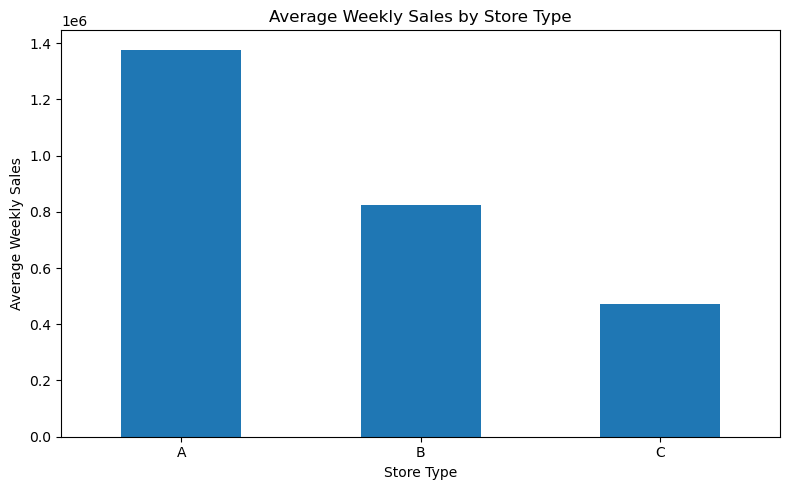

In [12]:
sales_by_type = (
    analysis_df.groupby("Type")["Weekly_Sales"]
    .mean()
    .sort_values(ascending=False)
)

display(sales_by_type.to_frame("Average Weekly Sales").round(2))

sales_by_type.plot(kind="bar", figsize=(8,5))
plt.title("Average Weekly Sales by Store Type")
plt.xlabel("Store Type")
plt.ylabel("Average Weekly Sales")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Interpretation
Type A stores generated the highest average weekly sales at approximately **$1.38 million**, compared with about **$0.82 million** for Type B and **$0.47 million** for Type C. This indicates that store format is strongly associated with sales performance.


## 10. Relationship Between Store Size and Weekly Sales


Correlation between store size and weekly sales: 0.81


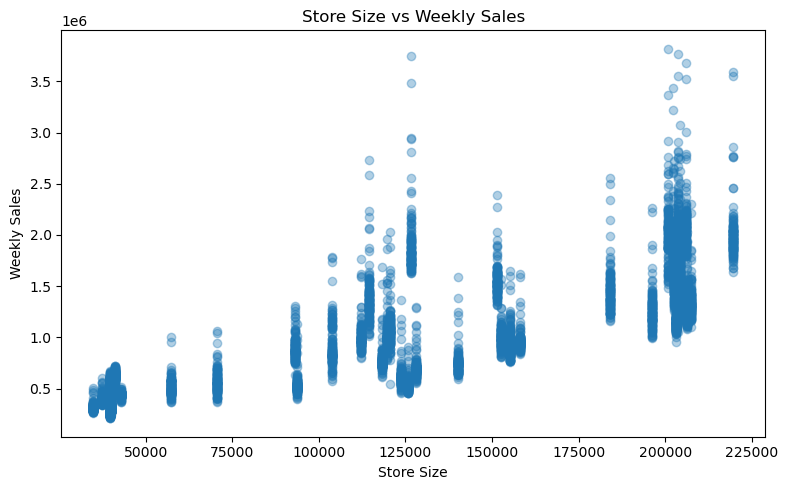

In [13]:
size_sales_corr = analysis_df["Size"].corr(analysis_df["Weekly_Sales"])
print("Correlation between store size and weekly sales:", round(size_sales_corr, 3))

plt.figure(figsize=(8,5))
plt.scatter(analysis_df["Size"], analysis_df["Weekly_Sales"], alpha=0.35)
plt.title("Store Size vs Weekly Sales")
plt.xlabel("Store Size")
plt.ylabel("Weekly Sales")
plt.tight_layout()
plt.show()

### Interpretation
Store size has a strong positive correlation with weekly sales (**r = 0.81**). Larger stores therefore tend to generate substantially higher weekly sales, making store size one of the clearest structural drivers in the dataset.


## 11. Holiday vs Non-Holiday Sales


,Average Weekly Sales
IsHoliday,
Non-Holiday,1041256.38
Holiday,1122887.89


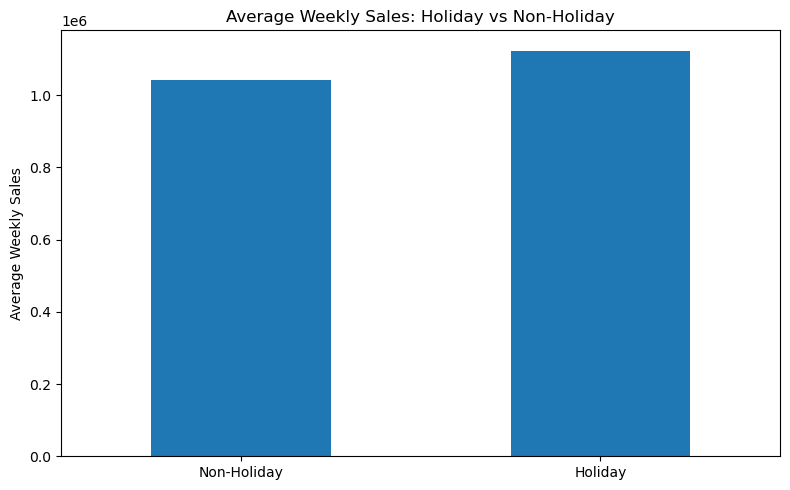

In [14]:
holiday_sales = (
    analysis_df.groupby("IsHoliday")["Weekly_Sales"]
    .mean()
    .rename(index={False: "Non-Holiday", True: "Holiday"})
)

display(holiday_sales.to_frame("Average Weekly Sales").round(2))

holiday_sales.plot(kind="bar", figsize=(8,5))
plt.title("Average Weekly Sales: Holiday vs Non-Holiday")
plt.xlabel("")
plt.ylabel("Average Weekly Sales")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [15]:
holiday_change = (
    (holiday_sales["Holiday"] - holiday_sales["Non-Holiday"])
    / holiday_sales["Non-Holiday"]
) * 100

print(f"Holiday weeks have {holiday_change:.2f}% higher/lower average weekly sales than non-holiday weeks.")

Holiday weeks have 7.84% higher/lower average weekly sales than non-holiday weeks.


### Interpretation
Average weekly sales were approximately **$1.12 million** during holiday weeks versus **$1.04 million** during non-holiday weeks. Holiday weeks therefore generated about **7.84% higher average sales**, indicating a meaningful seasonal demand effect.


## 12. Top Performing Stores

Store performance is ranked using average weekly sales across the observed period.


,Average Weekly Sales
Store,
20,2107676.87
4,2094712.96
14,2020978.40
13,2003620.31
2,1925751.34
10,1899424.57
27,1775216.20
6,1564728.19
1,1555264.40


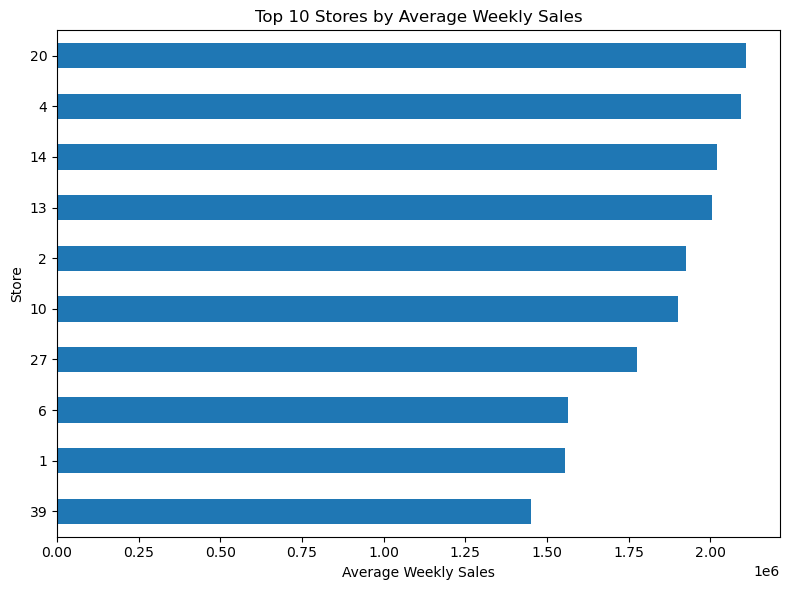

In [16]:
top_stores = (
    analysis_df.groupby("Store")["Weekly_Sales"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

display(top_stores.to_frame("Average Weekly Sales").round(2))

top_stores.sort_values().plot(kind="barh", figsize=(8,6))
plt.title("Top 10 Stores by Average Weekly Sales")
plt.xlabel("Average Weekly Sales")
plt.ylabel("Store")
plt.tight_layout()
plt.show()

## 13. Sales Trend Over Time


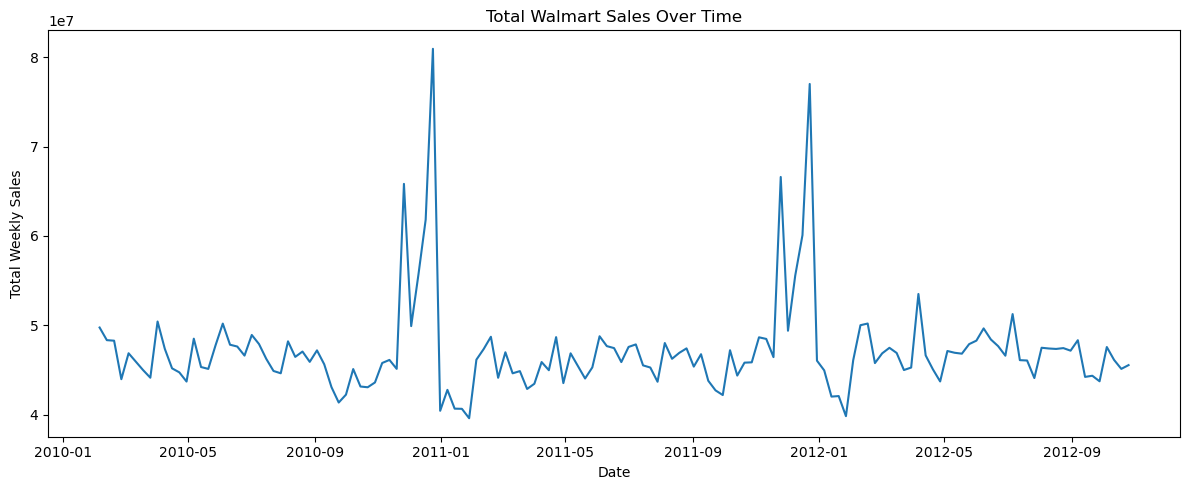

In [17]:
weekly_total = (
    analysis_df.groupby("Date")["Weekly_Sales"]
    .sum()
)

plt.figure(figsize=(12,5))
plt.plot(weekly_total.index, weekly_total.values)
plt.title("Total Walmart Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Total Weekly Sales")
plt.tight_layout()
plt.show()

## 14. Monthly Sales Pattern


,Average Weekly Sales
Month,
1,923884.55
2,1053199.80
3,1013309.23
4,1026761.56
5,1031714.02
6,1064324.59
7,1031747.58
8,1048017.45
9,989335.35


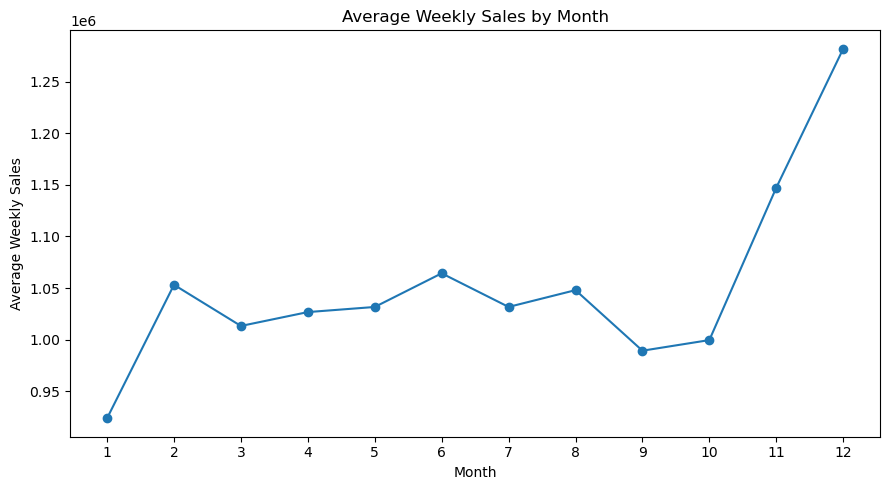

In [18]:
monthly_sales = (
    analysis_df.groupby("Month")["Weekly_Sales"]
    .mean()
)

display(monthly_sales.to_frame("Average Weekly Sales").round(2))

plt.figure(figsize=(9,5))
plt.plot(monthly_sales.index, monthly_sales.values, marker="o")
plt.title("Average Weekly Sales by Month")
plt.xlabel("Month")
plt.ylabel("Average Weekly Sales")
plt.xticks(range(1,13))
plt.tight_layout()
plt.show()

### Interpretation
December recorded the highest average weekly sales at approximately **$1.28 million**, followed by November at about **$1.15 million**. This suggests a strong year-end seasonal effect, likely linked to holiday shopping activity.


## 15. Correlation Analysis

The correlation analysis evaluates the linear relationship between weekly sales and store size, holidays, temperature, fuel prices, CPI, and unemployment.


In [19]:
correlation_columns = [
    "Weekly_Sales",
    "Size",
    "Temperature",
    "Fuel_Price",
    "CPI",
    "Unemployment",
    "IsHoliday"
]

correlations = (
    analysis_df[correlation_columns]
    .corr(numeric_only=True)["Weekly_Sales"]
    .sort_values(ascending=False)
)

display(correlations.to_frame("Correlation with Weekly Sales").round(3))

,Correlation with Weekly Sales
Weekly_Sales,1.000
Size,0.810
IsHoliday,0.037
Fuel_Price,0.009
Temperature,-0.064
CPI,-0.073
Unemployment,-0.106


### Interpretation
Store size shows by far the strongest relationship with weekly sales (**r = 0.81**). The remaining variables have only weak linear relationships with sales: holidays are slightly positive, while unemployment, CPI, and temperature are slightly negative. These correlations describe association rather than causation.


# SQL Analysis

The cleaned dataset is loaded into SQLite to reproduce key business analyses using SQL.


In [20]:
conn = sqlite3.connect(":memory:")

analysis_df.to_sql(
    "sales",
    conn,
    index=False,
    if_exists="replace"
)

print("SQL table created successfully.")

SQL table created successfully.


## 16. SQL — Average Sales by Store Type


In [21]:
query = '''
SELECT Type,
       ROUND(AVG(Weekly_Sales), 2) AS Avg_Weekly_Sales
FROM sales
GROUP BY Type
ORDER BY Avg_Weekly_Sales DESC;
'''

pd.read_sql_query(query, conn)

,Type,Avg_Weekly_Sales
0,A,1376673.47
1,B,822994.96
2,C,472614.83


## 17. SQL — Top 10 Stores


In [22]:
query = '''
SELECT Store,
       ROUND(AVG(Weekly_Sales), 2) AS Avg_Weekly_Sales
FROM sales
GROUP BY Store
ORDER BY Avg_Weekly_Sales DESC
LIMIT 10;
'''

pd.read_sql_query(query, conn)

,Store,Avg_Weekly_Sales
0,20,2107676.87
1,4,2094712.96
2,14,2020978.40
3,13,2003620.31
4,2,1925751.34
5,10,1899424.57
6,27,1775216.20
7,6,1564728.19
8,1,1555264.40
9,39,1450668.13


## 18. SQL — Average Sales by Year


In [23]:
query = '''
SELECT Year,
       ROUND(AVG(Weekly_Sales), 2) AS Avg_Weekly_Sales
FROM sales
GROUP BY Year
ORDER BY Year;
'''

pd.read_sql_query(query, conn)

,Year,Avg_Weekly_Sales
0,2010,1059669.50
1,2011,1046239.32
2,2012,1033660.39


# Simple Predictive Model

A linear regression model is used to estimate weekly sales from store size, temperature, fuel price, CPI, unemployment, and holiday status. The model is intentionally simple and is used to assess explanatory power rather than to build a production forecasting system.


## 19. Prepare Variables for the Model


In [24]:
model_df = analysis_df[
    [
        "Weekly_Sales",
        "Size",
        "Temperature",
        "Fuel_Price",
        "CPI",
        "Unemployment",
        "IsHoliday"
    ]
].copy()

model_df["IsHoliday"] = model_df["IsHoliday"].astype(int)

X = model_df.drop("Weekly_Sales", axis=1)
y = model_df["Weekly_Sales"]

display(X.head())

,Size,Temperature,Fuel_Price,CPI,Unemployment,IsHoliday
0,151315,42.31,2.572,211.096358,8.106,0
1,151315,38.51,2.548,211.242170,8.106,1
2,151315,39.93,2.514,211.289143,8.106,0
3,151315,46.63,2.561,211.319643,8.106,0
4,151315,46.50,2.625,211.350143,8.106,0


## 20. Train-Test Split


In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

Training rows: 5148
Testing rows: 1287


## 21. Train the Linear Regression Model


In [26]:
model = LinearRegression()
model.fit(X_train, y_train)

print("Model trained successfully.")

Model trained successfully.


## 22. Evaluate the Model


In [27]:
predictions = model.predict(X_test)

mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print(f"Mean Absolute Error: {mae:,.2f}")
print(f"R-squared: {r2:.3f}")

Mean Absolute Error: 247,929.46
R-squared: 0.662


### Model Performance
The model achieved an **R² of 0.662**, meaning that the included variables explain about **66.2% of the variation in weekly store sales**. The mean absolute error was approximately **$247,929**, so predicted weekly sales differed from actual sales by about $248k on average.


## 23. Model Coefficients


In [28]:
coefficients = pd.DataFrame({
    "Variable": X.columns,
    "Coefficient": model.coef_
}).sort_values("Coefficient", key=abs, ascending=False)

display(coefficients)

,Variable,Coefficient
5,IsHoliday,101179.901396
2,Fuel_Price,-28604.752628
4,Unemployment,-21195.010963
1,Temperature,1504.812895
3,CPI,-1373.340754
0,Size,7.211027


### Interpretation
Holiday weeks are associated with higher predicted sales, while fuel prices, unemployment, and CPI have negative estimated relationships with weekly sales. Because the predictors use different units, coefficient magnitudes should not be compared directly.


## 24. Actual vs Predicted Sales


,Actual Sales,Predicted Sales
0,1138800.32,9.867135e+05
1,1304850.67,1.609338e+06
2,1769296.25,1.514484e+06
3,1077640.13,1.218671e+06
4,428851.99,3.396303e+05
5,1004523.59,1.291282e+06
6,1523410.71,1.559850e+06
7,1014898.78,9.338287e+05
8,1955896.59,1.572672e+06
9,958667.23,9.324870e+05


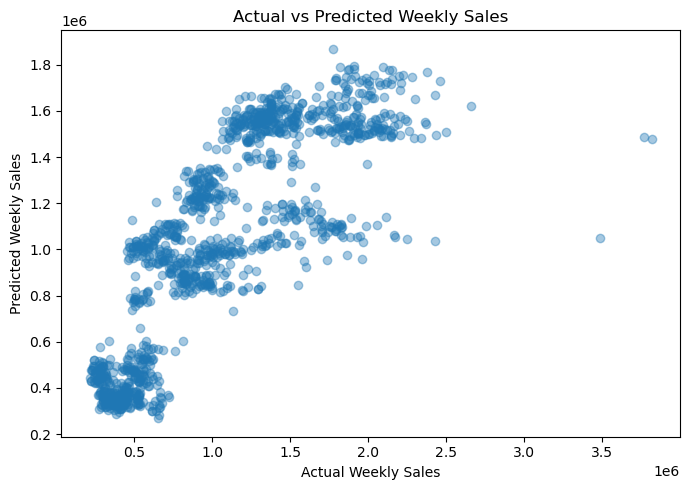

In [29]:
comparison = pd.DataFrame({
    "Actual Sales": y_test.values,
    "Predicted Sales": predictions
})

display(comparison.head(10))

plt.figure(figsize=(7,5))
plt.scatter(y_test, predictions, alpha=0.4)
plt.xlabel("Actual Weekly Sales")
plt.ylabel("Predicted Weekly Sales")
plt.title("Actual vs Predicted Weekly Sales")
plt.tight_layout()
plt.show()

# 25. Final Business Conclusions

### Key Findings
1. **Store size is the strongest sales driver in the dataset.** Its correlation with weekly sales is **0.81**, indicating that larger stores tend to generate substantially higher sales.
2. **Store format matters.** Type A stores recorded the highest average weekly sales at approximately **$1.38 million**, followed by Type B at **$0.82 million** and Type C at **$0.47 million**.
3. **Holiday weeks perform better.** Average weekly sales were about **7.84% higher** during holiday weeks than during non-holiday weeks.
4. **Sales show clear seasonality.** December had the highest average weekly sales at approximately **$1.28 million**, followed by November at about **$1.15 million**.
5. **External economic variables have relatively weak direct relationships with sales.** Unemployment had the strongest negative correlation among them at **-0.106**, while CPI, temperature, and fuel prices were also weakly related to sales.
6. **The regression model explains a substantial share of sales variation.** The model achieved an **R² of 0.662**, meaning that roughly **66.2%** of the variation in weekly store sales is explained by the included variables.

### Business Recommendations
- Use **store size and store type** as core inputs when setting sales benchmarks and comparing store performance.
- Increase **inventory and staffing preparation in November and December**, when average weekly sales are highest.
- Plan separately for **holiday weeks**, which generate materially higher sales than regular weeks.
- Treat macroeconomic indicators such as CPI, unemployment, and fuel prices as **supporting variables**, since their direct relationships with weekly sales are relatively weak in this dataset.
- Improve future forecasting by incorporating department-level sales, markdown activity, and additional local demand variables.

### Limitations
- Store identities are anonymized, so local market differences cannot be directly evaluated.
- The dataset covers a historical period and may not reflect current retail conditions.
- Correlation does not establish causation.
- The regression model is intentionally simple and does not include all possible drivers of sales.

## Conclusion
The analysis shows that **store characteristics and seasonal demand patterns are more informative for explaining weekly sales than the external economic variables included in the dataset**. A simple linear regression model captures a meaningful share of sales variation and provides a clear baseline for further retail forecasting work.


## 26. Export the Cleaned Dataset


In [31]:
analysis_df.to_csv("cleaned_store_week_sales.csv", index=False)

print("Cleaned dataset exported successfully.")


Cleaned dataset exported successfully.
